# Pipeline IoT CENTINELA+ — explicación de las 5 capas

> _Tutorial · Caso de uso: **A — Pipeline IoT CENTINELA+** · Capa Medallion: **bronce → plata** · Spec: `docs/specs/synthetic-bms/03-architecture-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Comprender de extremo a extremo cómo CENTINELA+ recibe un dato real (sensor → MQTT → Telegraf → InfluxDB → Grafana) y por qué este proyecto reproduce ese mismo flujo con un generador sintético.


## 2. Qué se aprende

- Las 5 capas de CENTINELA+ y la responsabilidad de cada una.
- Por qué Mosquitto y Telegraf no se comunican con la BD directamente.
- Cómo se garantiza la entrega de mensajes (QoS 1, durabilidad).
- Routing on-change vs continuo (telemetry vs state_events).
- Vocabulario para todos los notebooks de este caso.


## 3. Contexto del caso de uso

Caso A es el único caso de uso del proyecto que reproduce el pipeline IoT completo. El resto de equipos puede insertar directamente en InfluxDB; este equipo simula como si fuesen sensores reales.


## 4. Relación con CENTINELA+

Cada componente de este notebook es **idéntico** al desplegado en el edge server del IES Simarro. Cuando los sensores reales generen datos suficientes, basta con reorientar Telegraf al Mosquitto del edificio.


## 5. Relación con Medallion

El equipo del Caso A vive en la frontera **bronce → plata**. El payload MQTT que sale del sensor es bronce; lo que entra a InfluxDB es plata.


## 6. Datos de entrada

Conceptual: no cargamos datasets. Mostraremos un payload de ejemplo y explicaremos cómo viaja por las capas.


## 8. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

El topic MQTT y el payload JSON; la línea final en InfluxDB.


In [2]:
topic = build_topic(env="dev", tenant="default", site="ies_simarro",
                    asset="AULA01", variable="co2")
payload = {"value": 712, "ts_ns": int(pd.Timestamp("2026-05-10T08:00:00Z").value)}
print("topic:", topic)
print("payload:", payload)


topic: captia/dev/default/ies_simarro/AULA01/telemetry/co2
payload: {'value': 712, 'ts_ns': 1778400000000000000}


## 9. Carga de datos o mock

Construimos un dataframe `flujo` que enumera cada capa, su tecnología, su responsabilidad y el formato de los datos que la atraviesan.


In [3]:
flujo = pd.DataFrame(
    [
        ("1 sensores", "BME680, Sensup, gateway BMS", "publica MQTT 5s", "{value, ts_ns} JSON"),
        ("2 broker MQTT", "Mosquitto 2.0", "ACLs, QoS 1, persistencia", "topic + payload"),
        ("3 ingesta", "Telegraf 1.32", "regex 5 tags, dedup on-change", "line protocol"),
        ("4 BD series", "InfluxDB 2.7 (7 buckets)", "raw + rollups", "captia_point"),
        ("5 visualización", "Grafana 11 + Adapter", "dashboards, cache Redis", "queries Flux"),
    ],
    columns=["capa", "tecnología", "responsabilidad", "formato datos"],
)
flujo


,capa,tecnología,responsabilidad,formato datos
0,1 sensores,"BME680, Sensup, gateway BMS",publica MQTT 5s,"{value, ts_ns} JSON"
1,2 broker MQTT,Mosquitto 2.0,"ACLs, QoS 1, persistencia",topic + payload
2,3 ingesta,Telegraf 1.32,"regex 5 tags, dedup on-change",line protocol
3,4 BD series,InfluxDB 2.7 (7 buckets),raw + rollups,captia_point
4,5 visualización,Grafana 11 + Adapter,"dashboards, cache Redis",queries Flux


## 10. Exploración paso a paso

Pintamos un diagrama Mermaid en una celda Markdown que se renderiza en Jupyter (con la extensión correspondiente) y también en MkDocs Material.


In [4]:
from IPython.display import Markdown
Markdown('''```mermaid
flowchart LR
  S[Sensor BMS\nMQTT] --> M[Mosquitto\nQoS 1]
  M --> T[Telegraf\nregex + dedup]
  T --> I[(InfluxDB\n7 buckets)]
  I --> G[Grafana\ndashboards]
  T -. /metrics .-> P[Prometheus]
  G <-. cache .-> R[(Redis)]
```''')


```mermaid
flowchart LR
  S[Sensor BMS
MQTT] --> M[Mosquitto
QoS 1]
  M --> T[Telegraf
regex + dedup]
  T --> I[(InfluxDB
7 buckets)]
  I --> G[Grafana
dashboards]
  T -. /metrics .-> P[Prometheus]
  G <-. cache .-> R[(Redis)]
```

## 11. Transformación bronce → plata

Telegraf se configura con un único bloque `mqtt_consumer` y dos outputs (uno a `telemetry`, otro a `state_events`). Reproducimos una versión minimal del fichero TOML.


In [5]:
telegraf_minimal = '''
[[inputs.mqtt_consumer]]
  servers = ["tcp://mosquitto:1883"]
  topics  = ["captia/+/+/+/+/telemetry/+", "captia/+/+/+/+/event/+"]
  name_override = "captia_point"
  data_format = "json"

[[processors.regex.tags]]
  key = "topic"
  pattern = "captia/([^/]+)/([^/]+)/([^/]+)/([^/]+)/[^/]+/([^/]+)"
  result_key = "captia_env"  # idem para domain_id, site_id, asset_id, variable

[[outputs.influxdb_v2]]
  bucket = "telemetry"
  fieldpass = ["value"]
'''
print(telegraf_minimal)



[[inputs.mqtt_consumer]]
  servers = ["tcp://mosquitto:1883"]
  topics  = ["captia/+/+/+/+/telemetry/+", "captia/+/+/+/+/event/+"]
  name_override = "captia_point"
  data_format = "json"

[[processors.regex.tags]]
  key = "topic"
  pattern = "captia/([^/]+)/([^/]+)/([^/]+)/([^/]+)/[^/]+/([^/]+)"
  result_key = "captia_env"  # idem para domain_id, site_id, asset_id, variable

[[outputs.influxdb_v2]]
  bucket = "telemetry"
  fieldpass = ["value"]



## 12. Construcción de capa oro

El equipo Caso A no construye capa oro: su entregable es el pipeline. El **valor** queda en los dashboards Grafana y en la documentación.


## 13. Visualizaciones explicativas

Pintamos un timeline ficticio de la latencia esperada por capa (ms).


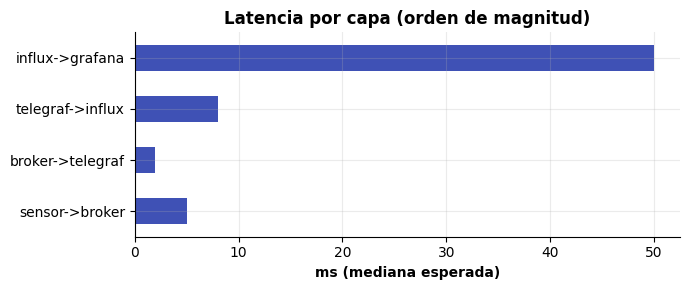

In [6]:
latencias_ms = pd.Series(
    {"sensor->broker": 5, "broker->telegraf": 2, "telegraf->influx": 8, "influx->grafana": 50},
)
ax = latencias_ms.plot.barh(color="#3F51B5", figsize=(7, 3))
ax.set_xlabel("ms (mediana esperada)")
ax.set_title("Latencia por capa (orden de magnitud)")
plt.tight_layout()


## 14. Validaciones

Confirmamos que el topic generado cumple el contrato (6 niveles, `telemetry` o `event`).


In [7]:
assert topic.count("/") == 6
parts = topic.split("/")
assert parts[0] == "captia"
assert parts[5] in {"telemetry", "event"}
print("Topic OK:", topic)


Topic OK: captia/dev/default/ies_simarro/AULA01/telemetry/co2


## 15. Errores comunes

1. **Cambiar el orden del topic**. Telegraf no parsea y el dato se descarta.
2. **Olvidar `fieldpass = ['value']`**. Aparecen fields adicionales que rompen `count(_field=='value')`.
3. **Publicar con QoS 0**. En entornos lossy los puntos se pierden silenciosamente.
4. **No tener `captia_metadata` poblado**. Las tareas Flux de downsampling no emiten para esa variable.


## 16. Ejercicios propuestos

1. Añade un nivel `floor` al topic y enumera los cambios necesarios en Telegraf.
2. Diseña un payload alternativo `{value, ts}` con ISO 8601 y discute pros/contras.
3. Calcula cuántos mensajes/segundo debe sostener Telegraf con 70 aulas y 22 variables.


## 17. Cómo se reutiliza con datos reales

Cuando los sensores físicos del IES Simarro publiquen, basta con apuntar Telegraf al Mosquitto del edge server (100.102.212.105) y Telegraf escribirá en el InfluxDB local. El código no cambia.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `01_case_A_pipeline_iot/02_publicacion_mqtt_a_influxdb.ipynb`.
- Documento web del caso: `docs/use-cases/case-a-pipeline-iot.md`.
